# Artificial Intelligence Technology and Application

## Machine Learning Lab Guide - Student Version

Independent implementation prepared by **Sundetkhan Bekzat**.


# 1 Implementation of Common Machine Learning Algorithms

This notebook keeps the lab objective but uses compact local examples so it can run without external datasets.


## 1.1 Linear Regression
A noisy synthetic dataset is used to estimate a continuous target.


coef: 6.023 intercept: 45.077
rmse: 4.676
r2: 0.924


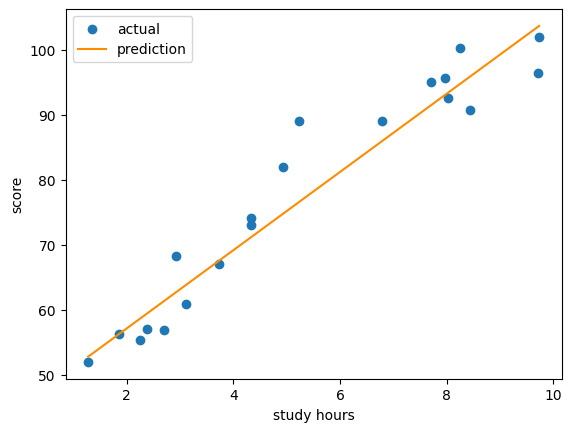

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

rng = np.random.default_rng(42)
study_hours = rng.uniform(1, 10, size=80).reshape(-1, 1)
score = 47 + 5.8 * study_hours.ravel() + rng.normal(0, 4, size=80)
X_train, X_test, y_train, y_test = train_test_split(study_hours, score, random_state=42)

reg = LinearRegression().fit(X_train, y_train)
predicted = reg.predict(X_test)
print("coef:", round(reg.coef_[0], 3), "intercept:", round(reg.intercept_, 3))
print("rmse:", round(mean_squared_error(y_test, predicted) ** 0.5, 3))
print("r2:", round(r2_score(y_test, predicted), 3))
plt.scatter(X_test.ravel(), y_test, label="actual")
order = np.argsort(X_test.ravel())
plt.plot(X_test.ravel()[order], predicted[order], color="darkorange", label="prediction")
plt.xlabel("study hours")
plt.ylabel("score")
plt.legend()
plt.show()


## 1.2 Logistic Regression
The classifier separates two generated classes after feature scaling.


In [2]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

features, labels = make_classification(
    n_samples=180, n_features=4, n_informative=3, n_redundant=0, random_state=7
)
X_train, X_test, y_train, y_test = train_test_split(features, labels, stratify=labels, random_state=7)
scaler = StandardScaler().fit(X_train)
model = LogisticRegression(max_iter=500).fit(scaler.transform(X_train), y_train)
pred = model.predict(scaler.transform(X_test))
print("accuracy:", round(accuracy_score(y_test, pred), 3))
print(confusion_matrix(y_test, pred))


accuracy: 0.778
[[19  3]
 [ 7 16]]


## 1.3 K-Means Clustering
Unlabeled samples are grouped by geometric distance to centroids.


centers:
[[-1.65 -0.29]
 [-6.24 -9.67]
 [-0.95  4.61]]


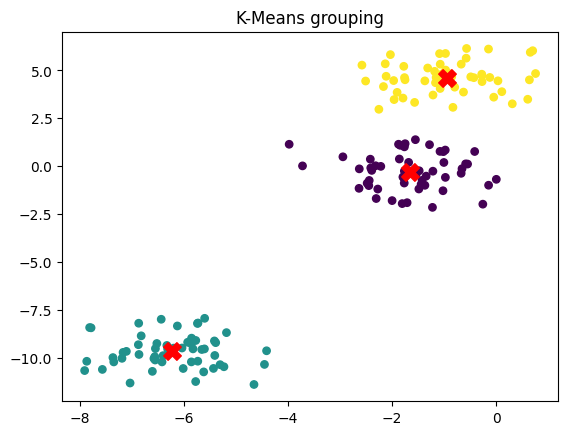

In [3]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

points, _ = make_blobs(n_samples=160, centers=3, cluster_std=0.9, random_state=11)
clusterer = KMeans(n_clusters=3, random_state=11, n_init=10)
groups = clusterer.fit_predict(points)
print("centers:")
print(clusterer.cluster_centers_.round(2))
plt.scatter(points[:, 0], points[:, 1], c=groups, cmap="viridis", s=28)
plt.scatter(clusterer.cluster_centers_[:, 0], clusterer.cluster_centers_[:, 1], marker="X", s=160, c="red")
plt.title("K-Means grouping")
plt.show()


## 1.4 Decision Tree
A tree model gives an interpretable baseline for tabular classification.


In [4]:
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, random_state=4, stratify=iris.target)
tree_model = DecisionTreeClassifier(max_depth=3, random_state=4).fit(X_train, y_train)
print("tree accuracy:", round(accuracy_score(y_test, tree_model.predict(X_test)), 3))
print("feature importance:", dict(zip(iris.feature_names, tree_model.feature_importances_.round(3))))


tree accuracy: 0.974
feature importance: {'sepal length (cm)': np.float64(0.0), 'sepal width (cm)': np.float64(0.0), 'petal length (cm)': np.float64(0.582), 'petal width (cm)': np.float64(0.418)}
